In [1]:
!pip install -q \
  datasets==2.18.0 \
  transformers==4.39.3 \
  tokenizers==0.15.2 \
  accelerate==0.28.0 \
  peft==0.10.0 \
  soundfile \
  jiwer \
  pyarrow_hotfix \
  --no-deps
!pip install evaluate
!pip install rapidfuzz
!pip install transformers -U
!pip install 'accelerate>=1.1.0'
!pip install peft accelerate bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 119.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.1/290.1 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 17.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fss

In [2]:
import torch
from datasets import load_dataset, Audio
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)
import evaluate
from jiwer import process_words
import numpy as np
import pandas as pd

In [3]:
# pushing to hub
from huggingface_hub import login

from google.colab import userdata


hf_token = userdata.get('hf_token')

login(token=hf_token)

In [4]:
import os

from datasets import load_dataset, Audio

# 2. Load the dataset using the EXACT name of the folder
dataset = load_dataset(
    "kkarhm/nepali-english-codemixed-asr",
    split='train'
)

# 3. Cast Audio (decode=True uncompresses it on the fly)
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000, decode=True))

# # 4. Split dataset
split_dataset = dataset.train_test_split(test_size=0.01, seed=67)

print("Successfully loaded locally!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/137405 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/25 [00:00<?, ?it/s]

Successfully loaded locally!


In [5]:
os.environ["HF_TOKEN"] = hf_token

In [6]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration





processor = WhisperProcessor.from_pretrained("openai/whisper-small")
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")

# Configure your generation settings
model.generation_config.forced_decoder_ids = None
model.generation_config.suppress_tokens = None
model.generation_config.task = "transcribe"

model.config.forced_decoder_ids = None
model.config.suppress_tokens = None

processor.tokenizer.pad_token = processor.tokenizer.eos_token
model.config.pad_token_id = processor.tokenizer.pad_token_id

print("Both Processor and Model are ready to go!")

preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Both Processor and Model are ready to go!


In [7]:
# special_token = "<|nep_eng|>"

# processor.tokenizer.add_special_tokens({
#     "additional_special_tokens": [special_token]
# })

# model.resize_token_embeddings(len(processor.tokenizer))

In [8]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none"
)

model = get_peft_model(model, lora_config)

In [9]:
if hasattr(model, "enable_input_require_grads"):
    model.enable_input_require_grads()
else:
    def make_inputs_require_grad(module, input, output):
        output.requires_grad_(True)
    model.get_input_embeddings().register_forward_hook(make_inputs_require_grad)

model.print_trainable_parameters()

trainable params: 1,769,472 || all params: 243,504,384 || trainable%: 0.7266694631666262


In [10]:
train_dataset = split_dataset["train"]
test_dataset = split_dataset["test"]

In [11]:
def prepare(batch):
    audio = batch["audio"]
    # IMPORTANT: Ensure audio is sampled at 16000Hz before this step!
    batch["input_features"] = processor.feature_extractor(
        audio["array"], sampling_rate=audio["sampling_rate"]
    ).input_features[0]

    batch["labels"] = processor.tokenizer(batch["text"]).input_ids
    return batch

# Assuming train_dataset and test_dataset are defined above
train_dataset = train_dataset.map(prepare, remove_columns=train_dataset.column_names)
test_dataset = test_dataset.map(prepare, remove_columns=test_dataset.column_names)

Map:   0%|          | 0/136030 [00:00<?, ? examples/s]

Map:   0%|          | 0/1375 [00:00<?, ? examples/s]

In [12]:
train_dataset

Dataset({
    features: ['input_features', 'labels'],
    num_rows: 136030
})

In [13]:
from dataclasses import dataclass
from typing import Any, Dict, List, Union

@dataclass
class DataCollatorSpeechSeq2Seq:
    processor: Any

    def __call__(self, features):
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(
            input_features, return_tensors="pt"
        )

        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(
            label_features, return_tensors="pt"
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch["attention_mask"].ne(1), -100
        )
        batch["labels"] = labels
        return batch

data_collator = DataCollatorSpeechSeq2Seq(processor)

In [14]:
# Load the metrics
wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

In [15]:
def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    preds = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    refs = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    wer = wer_metric.compute(predictions=preds, references=refs)
    cer = cer_metric.compute(predictions=preds, references=refs)

    measures = process_words(refs, preds)

    avg_len = np.mean([len(p.split()) for p in preds])

    return {
        "wer": wer,
        "cer": cer,
        "mer": measures.mer,
        "wil": measures.wil,
        "wip": measures.wip,
        "sub_rate": measures.substitutions / measures.hits,
        "del_rate": measures.deletions / measures.hits,
        "ins_rate": measures.insertions / measures.hits,
        "avg_pred_length": avg_len,
    }


In [19]:
training_args = Seq2SeqTrainingArguments(
    output_dir="./whisper-nepali",
    hub_model_id="kkarhm/whisper-nep-eng-codemixed-small",
    per_device_train_batch_size=250,
    per_device_eval_batch_size=100,
    gradient_accumulation_steps=1,
    learning_rate=5e-4,
    warmup_steps=100,
    num_train_epochs=2,
    fp16=True,
    gradient_checkpointing=True,
    eval_strategy="steps", # Note: 'evaluation_strategy' in older transformers versions
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    logging_steps=25,
    predict_with_generate=True,
    generation_max_length=225,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
    push_to_hub=True,
    remove_unused_columns=False,
    report_to="none"
)

In [20]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    processing_class=processor.feature_extractor,
    compute_metrics=compute_metrics, # Ensure this is defined in your actual script
)

In [21]:
trainer.train()

Step,Training Loss,Validation Loss,Wer,Cer,Mer,Wil,Wip,Sub Rate,Del Rate,Ins Rate,Avg Pred Length
100,0.784421,0.561431,0.459665,0.279957,0.449962,0.670093,0.329907,0.664826,0.114854,0.038377,8.973091
200,0.297711,0.294596,0.252948,0.107156,0.248476,0.409063,0.590937,0.271114,0.035993,0.023522,9.286545
300,0.254714,0.257565,0.210441,0.074109,0.206847,0.349059,0.650941,0.218110,0.021148,0.021532,9.378909
400,0.228847,0.230176,0.191281,0.063239,0.188604,0.323653,0.676347,0.199453,0.015741,0.017250,9.387636
500,0.212366,0.213271,0.182128,0.058894,0.180020,0.309863,0.690137,0.187938,0.017485,0.014119,9.349818
600,0.196869,0.203217,0.186472,0.069595,0.184059,0.313370,0.686630,0.188045,0.021676,0.015858,9.330909
700,0.188218,0.196854,0.178483,0.062227,0.176308,0.304046,0.695954,0.183349,0.015907,0.014791,9.367273
800,0.181348,0.188304,0.174294,0.061945,0.172290,0.295087,0.704913,0.173969,0.020287,0.013895,9.325818


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> to see related `.generate()` flags.


Step,Training Loss,Validation Loss,Wer,Cer,Mer,Wil,Wip,Sub Rate,Del Rate,Ins Rate,Avg Pred Length
100,0.784421,0.561431,0.459665,0.279957,0.449962,0.670093,0.329907,0.664826,0.114854,0.038377,8.973091
200,0.297711,0.294596,0.252948,0.107156,0.248476,0.409063,0.590937,0.271114,0.035993,0.023522,9.286545
300,0.254714,0.257565,0.210441,0.074109,0.206847,0.349059,0.650941,0.218110,0.021148,0.021532,9.378909
400,0.228847,0.230176,0.191281,0.063239,0.188604,0.323653,0.676347,0.199453,0.015741,0.017250,9.387636
500,0.212366,0.213271,0.182128,0.058894,0.180020,0.309863,0.690137,0.187938,0.017485,0.014119,9.349818
600,0.196869,0.203217,0.186472,0.069595,0.184059,0.313370,0.686630,0.188045,0.021676,0.015858,9.330909
700,0.188218,0.196854,0.178483,0.062227,0.176308,0.304046,0.695954,0.183349,0.015907,0.014791,9.367273
800,0.181348,0.188304,0.174294,0.061945,0.172290,0.295087,0.704913,0.173969,0.020287,0.013895,9.325818
900,0.175922,0.183309,0.177242,0.068147,0.175540,0.297484,0.702516,0.173313,0.027954,0.011647,9.248727
1000,0.174141,0.179804,0.166305,0.057544,0.164442,0.283774,0.716226,0.166422,0.016982,0.013402,9.347636


TrainOutput(global_step=1090, training_loss=0.33510384603377874, metrics={'train_runtime': 41416.5235, 'train_samples_per_second': 6.569, 'train_steps_per_second': 0.026, 'total_flos': 7.92057636864e+19, 'train_loss': 0.33510384603377874, 'epoch': 2.0})

In [22]:
model = trainer.model.merge_and_unload()
model = model.float()


model.push_to_hub("kkarhm/whisper-nep-eng-codemixed-peft-small")
processor.push_to_hub("kkarhm/whisper-nep-eng-codemixed-peft-small")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...6p0vctt/model.safetensors:   0%|          | 1.40MB /  967MB            

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/kkarhm/whisper-nep-eng-codemixed-peft-small/commit/85de2f2dd6d3abff54a95927d9885e1b8e4dff48', commit_message='Upload processor', commit_description='', oid='85de2f2dd6d3abff54a95927d9885e1b8e4dff48', pr_url=None, repo_url=RepoUrl('https://huggingface.co/kkarhm/whisper-nep-eng-codemixed-peft-small', endpoint='https://huggingface.co', repo_type='model', repo_id='kkarhm/whisper-nep-eng-codemixed-peft-small'), pr_revision=None, pr_num=None)

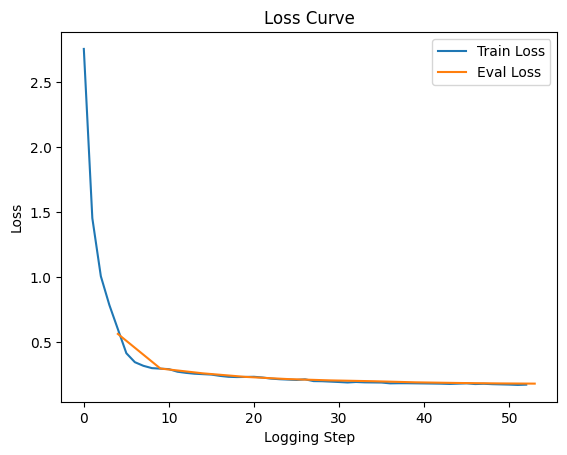

In [23]:
history = trainer.state.log_history
df = pd.DataFrame(history)
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["loss"].dropna(), label="Train Loss")
plt.plot(df["eval_loss"].dropna(), label="Eval Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Logging Step")
plt.ylabel("Loss")
plt.show()


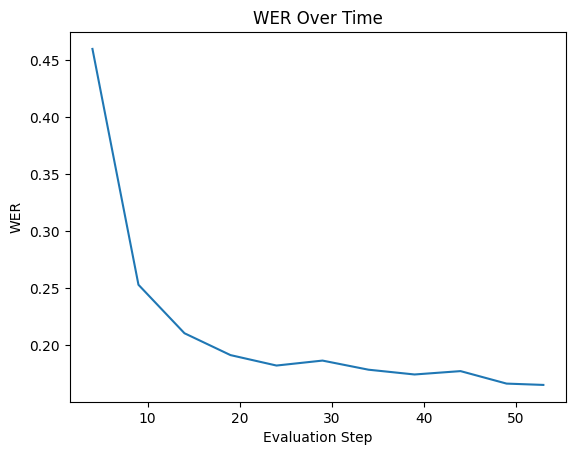

In [24]:
# wer
plt.figure()
plt.plot(df["eval_wer"].dropna())
plt.title("WER Over Time")
plt.xlabel("Evaluation Step")
plt.ylabel("WER")
plt.show()


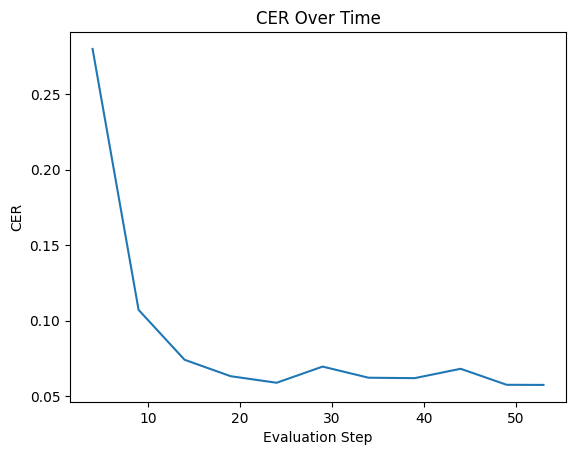

In [25]:
# cer
plt.figure()
plt.plot(df["eval_cer"].dropna())
plt.title("CER Over Time")
plt.xlabel("Evaluation Step")
plt.ylabel("CER")
plt.show()


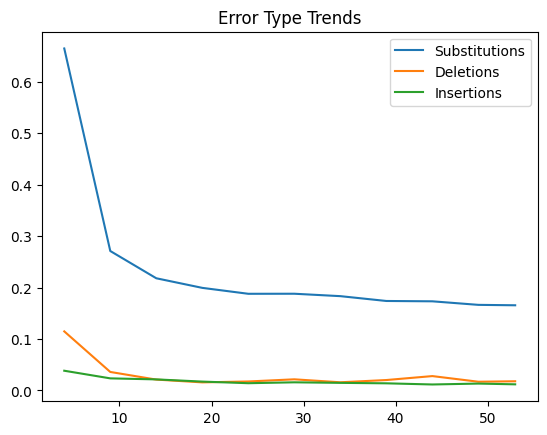

In [26]:
# error type evol
plt.figure()
plt.plot(df["eval_sub_rate"].dropna(), label="Substitutions")
plt.plot(df["eval_del_rate"].dropna(), label="Deletions")
plt.plot(df["eval_ins_rate"].dropna(), label="Insertions")
plt.legend()
plt.title("Error Type Trends")
plt.show()


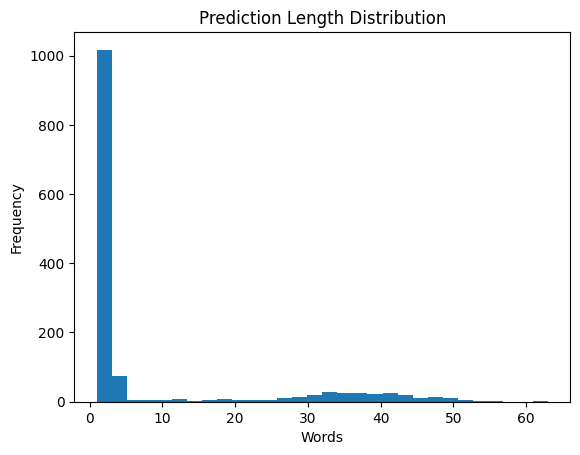

In [27]:
# pred len dist
preds = trainer.predict(test_dataset)

pred_text = processor.tokenizer.batch_decode(
    preds.predictions, skip_special_tokens=True
)

lengths = [len(p.split()) for p in pred_text]

plt.figure()
plt.hist(lengths, bins=30)
plt.title("Prediction Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()


In [29]:
# performance vs audio duration
durations = []
refs = []
preds_text = []

for sample, pred in zip(test_dataset[:200], pred_text):
    durations.append(len(sample["utterance"]["array"]) / 16000)
    refs.append(sample["transcription"])
    preds_text.append(pred)

from jiwer import wer
errors = [wer(r, p) for r, p in zip(refs, preds_text)]

plt.figure()
plt.scatter(durations, errors)
plt.xlabel("Audio Duration (seconds)")
plt.ylabel("WER")
plt.title("WER vs Audio Duration")
plt.show()


TypeError: string indices must be integers, not 'str'

In [ ]:
from collections import Counter

errors = []
for r, p in zip(refs, preds_text):
    if r != p:
        errors.append((r, p))

print(errors[:10])

In [ ]:
save_dir = "/kaggle/working/whisper-nepali-final"

trainer.save_model(save_dir)          # saves model + config
processor.save_pretrained(save_dir)   # saves tokenizer + feature extractor